# 7CS353 Machine Learning Lab &mdash; Assignment 6
### Multiple Linear Regression: Model Fitting, Diagnostics, and Refinement

**Name:** Atharv V Kulkarni
**PRN:** 245109074
**Class:** TY B.Tech CSE (B)

## Section 0: Load and Explore the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df=pd.read_csv("data_MLR.csv")
print(df.shape)
print(df.isnull().sum())
df.describe().round(2)

(1000, 12)
y      0
x1     0
x2     0
x3     0
x4     0
x5     0
x6     0
x7     0
x8     0
x9     0
x10    0
x11    0
dtype: int64


,y,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,-40.62,-0.03,-4.97,-0.09,-24.92,11.14,0.43,6.31,4.05,-10.03,9.98,-19.19
std,59.78,3.16,1.96,7.47,13.77,2.47,4.64,6.91,3.12,2.05,7.29,18.48
min,-179.59,-11.20,-11.66,-23.45,-66.82,7.21,-15.14,-21.25,-6.09,-17.17,-13.44,-81.88
25%,-83.24,-2.14,-6.15,-5.25,-34.10,9.20,-2.43,1.45,1.86,-11.46,4.94,-31.78
50%,-48.50,-0.15,-4.92,-0.20,-24.45,10.64,1.05,6.55,4.07,-10.02,9.92,-19.64
75%,-10.38,2.10,-3.57,5.03,-15.70,12.64,3.65,11.26,6.22,-8.56,15.11,-5.94
max,186.15,9.84,1.32,24.87,18.75,23.20,12.17,24.37,14.79,-2.78,30.44,45.81


## Step 1: Train/Test Split and Feature Scaling

In [2]:
X=df.drop(columns=["y"])
y=df["y"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler=StandardScaler().fit(X_train)
X_train_s=pd.DataFrame(scaler.transform(X_train),columns=X_train.columns,index=X_train.index)
X_test_s=pd.DataFrame(scaler.transform(X_test),columns=X_test.columns,index=X_test.index)

print("train shape:",X_train_s.shape,"test shape:",X_test_s.shape)

train shape: (800, 11) test shape: (200, 11)


## Step 2: Fit the Full Model

In [3]:
X_train_c=sm.add_constant(X_train_s)
model_full=sm.OLS(y_train,X_train_c).fit()
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.204
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     18.40
Date:                Wed, 23 Sep 2026   Prob (F-statistic):           5.86e-33
Time:                        22:37:08   Log-Likelihood:                -4310.9
No. Observations:                 800   AIC:                             8646.
Df Residuals:                     788   BIC:                             8702.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -41.0891      1.887    -21.776      0.0

## Step 3: Multicollinearity — Iterative VIF Reduction

In [4]:
features=list(X_train_s.columns)
vif_log=[]

while True:
    Xc=sm.add_constant(X_train_s[features])
    vif=pd.Series(
        [variance_inflation_factor(Xc.values,i) for i in range(Xc.shape[1])],
        index=Xc.columns
    ).drop("const")
    print(vif.sort_values(ascending=False))
    if vif.max()>10:
        drop_feat=vif.idxmax()
        features.remove(drop_feat)
        refit=sm.OLS(y_train,sm.add_constant(X_train_s[features])).fit()
        vif_log.append({"dropped":drop_feat,"vif":vif.max(),"adj_r2_after":refit.rsquared_adj})
        print("dropping",drop_feat,"vif=",vif.max(),"new adj r2=",refit.rsquared_adj)
    else:
        break

vif_log_df=pd.DataFrame(vif_log)
print(vif_log_df)
print("features remaining after VIF step:",features)

model_vif=sm.OLS(y_train,sm.add_constant(X_train_s[features])).fit()
print(model_vif.summary())

x4     83844.209474
x2     41297.827284
x1     38913.870322
x11     1438.137705
x10     1154.990260
x9       310.795057
x3         3.428246
x8         3.290475
x6         1.016716
x5         1.011393
x7         1.010967
dtype: float64
dropping x4 vif= 83844.20947434877 new adj r2= 0.1938736594684759
x11    1436.833433
x10    1154.042590
x9      310.447435
x1        3.428054
x3        3.426934
x8        3.285552
x2        1.016584
x6        1.016332
x7        1.010599
x5        1.009155
dtype: float64
dropping x11 vif= 1436.8334327362213 new adj r2= 0.19277184830268723
x1     3.424336
x3     3.422518
x8     3.283759
x10    3.266725
x9     1.018322
x6     1.015626
x7     1.010546
x2     1.007536
x5     1.004555
dtype: float64
  dropped           vif  adj_r2_after
0      x4  83844.209474      0.193874
1     x11   1436.833433      0.192772
features remaining after VIF step: ['x1', 'x2', 'x3', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10']
                            OLS Regression Results           

## Step 4: Influential Observations — Cook's Distance and DFFITS

n= 800 p= 10
cooks threshold (4/n): 0.005 flagged: 58
dffits threshold: 0.22360679774997896 flagged: 58
max cooks distance: 0.07321886494381469


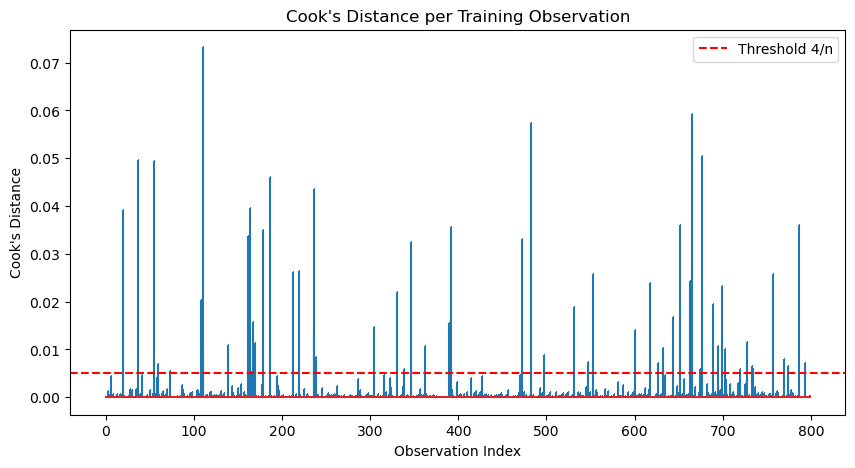

In [5]:
influence=OLSInfluence(model_vif)
cooks_d=influence.cooks_distance[0]
dffits_vals=influence.dffits[0]

n=len(y_train)
p=len(features)+1
cooks_thresh=4/n
dffits_thresh=2*np.sqrt(p/n)

flagged_cooks=np.where(cooks_d>cooks_thresh)[0]
flagged_dffits=np.where(np.abs(dffits_vals)>dffits_thresh)[0]

print("n=",n,"p=",p)
print("cooks threshold (4/n):",cooks_thresh,"flagged:",len(flagged_cooks))
print("dffits threshold:",dffits_thresh,"flagged:",len(flagged_dffits))
print("max cooks distance:",cooks_d.max())

plt.figure(figsize=(10,5))
plt.stem(range(n),cooks_d,markerfmt=",")
plt.axhline(cooks_thresh,color="red",linestyle="--",label="Threshold 4/n")
plt.title("Cook's Distance per Training Observation")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.legend()
plt.show()

## Step 5: Stepwise Significance Refinement

In [6]:
stepwise_features=features.copy()
current_model=model_vif
step_log=[]

while True:
    pvals=current_model.pvalues.drop("const")
    if pvals.max()>0.05:
        drop_feat=pvals.idxmax()
        trial_features=[f for f in stepwise_features if f!=drop_feat]
        trial_model=sm.OLS(y_train,sm.add_constant(X_train_s[trial_features])).fit()
        step_log.append({
            "dropped":drop_feat,
            "p_value":pvals.max(),
            "adj_r2_before":current_model.rsquared_adj,
            "adj_r2_after":trial_model.rsquared_adj
        })
        if trial_model.rsquared_adj<current_model.rsquared_adj:
            print("stopping - dropping",drop_feat,"would decrease adjusted r2")
            break
        stepwise_features=trial_features
        current_model=trial_model
    else:
        break

step_log_df=pd.DataFrame(step_log)
print(step_log_df)
print("final feature set:",stepwise_features)
print(current_model.summary())

stopping - dropping x7 would decrease adjusted r2
  dropped   p_value  adj_r2_before  adj_r2_after
0      x9  0.925848       0.192772      0.193784
1      x8  0.509234       0.193784      0.194358
2      x7  0.088284       0.194358      0.192415
final feature set: ['x1', 'x2', 'x3', 'x5', 'x6', 'x7', 'x10']
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.201
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     28.54
Date:                Wed, 23 Sep 2026   Prob (F-statistic):           3.69e-35
Time:                        22:37:14   Log-Likelihood:                -4312.4
No. Observations:                 800   AIC:                             8641.
Df Residuals:                     792   BIC:                             8678.
Df Model:                           7                      

## Step 6: Residual Diagnostics

**Step 6:** residuals vs fitted plot and Q-Q plot for the final model, to assess the LINE assumptions

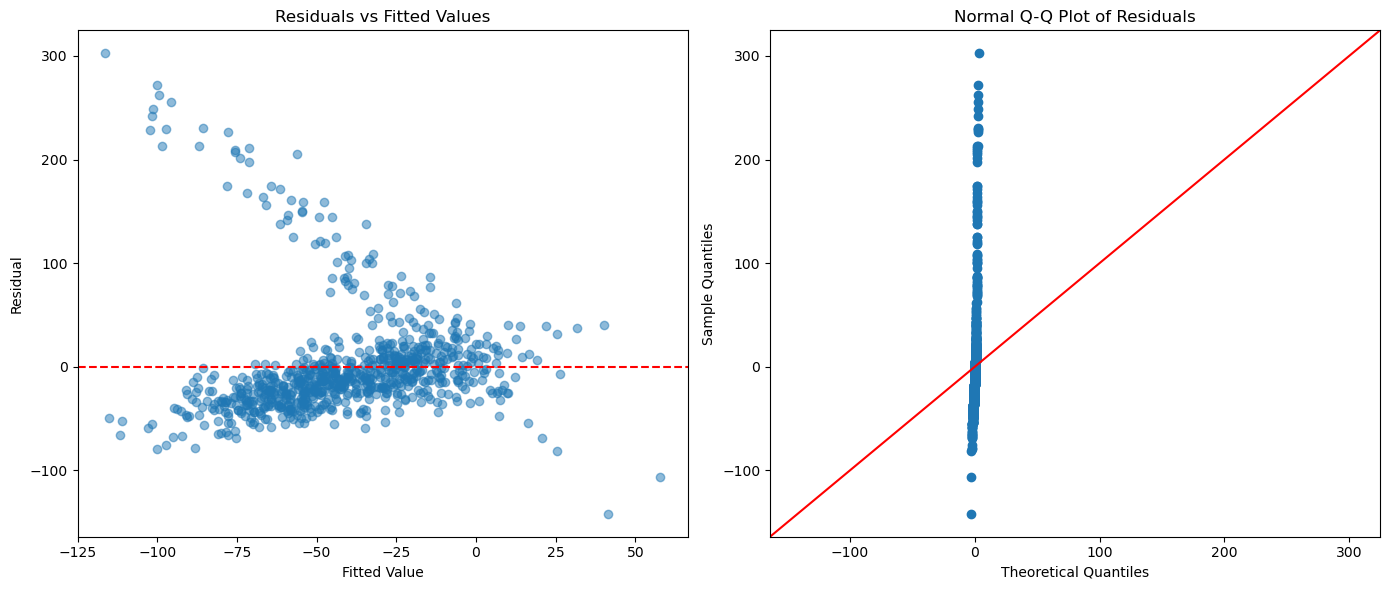

In [7]:
final_fitted=current_model.fittedvalues
final_resid=current_model.resid

fig,ax=plt.subplots(1,2,figsize=(14,6))
ax[0].scatter(final_fitted,final_resid,alpha=0.5)
ax[0].axhline(0,color="red",linestyle="--")
ax[0].set_title("Residuals vs Fitted Values")
ax[0].set_xlabel("Fitted Value")
ax[0].set_ylabel("Residual")

sm.qqplot(final_resid,line="45",ax=ax[1])
ax[1].set_title("Normal Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

## Step 7: Final Model and Test Set Evaluation

In [8]:
final_features=stepwise_features
X_test_final=sm.add_constant(X_test_s[final_features],has_constant="add")
y_pred_test=current_model.predict(X_test_final)

mae=mean_absolute_error(y_test,y_pred_test)
rmse=np.sqrt(mean_squared_error(y_test,y_pred_test))
r2_test=r2_score(y_test,y_pred_test)

results=pd.DataFrame({
    "Metric":["MAE","RMSE","R2 (test)","Adjusted R2 (train)"],
    "Value":[mae,rmse,r2_test,current_model.rsquared_adj]
})
print(results)
print(current_model.params)

                Metric      Value
0                  MAE  33.546490
1                 RMSE  51.843269
2            R2 (test)   0.281514
3  Adjusted R2 (train)   0.194358
const   -41.089086
x1        9.698405
x2       10.907373
x3       12.910101
x5        6.218291
x6        6.250751
x7       -3.229479
x10       4.300035
dtype: float64


| Metric | Value |
|---|---|
| MAE | 33.54 |
| RMSE | 51.84 |
| R² (test) | 0.28 |
| Adjusted R² (train) | 0.19 |